## Load data


In [92]:
import pandas as pd
import json

In [93]:
alert_sample = pd.read_json('dataset/alerts_sample.jsonl', lines=True).to_dict(orient='records')
for alert in alert_sample:
    print(alert)    

{'id': 'a-0001', 'ts': '2026-06-12T09:42:01Z', 'service': 'payment-svc', 'metric': 'db_connection_pool_used_ratio', 'severity': 'warn', 'value': 0.85, 'threshold': 0.8, 'labels': {'env': 'prod', 'region': 'ap-southeast-1'}}
{'id': 'a-0002', 'ts': '2026-06-12T09:42:18Z', 'service': 'payment-svc', 'metric': 'db_connection_pool_used_ratio', 'severity': 'crit', 'value': 0.99, 'threshold': 0.9500000000000001, 'labels': {'env': 'prod', 'region': 'ap-southeast-1'}}
{'id': 'a-0003', 'ts': '2026-06-12T09:42:22Z', 'service': 'payment-svc', 'metric': 'latency_p99_ms', 'severity': 'crit', 'value': 1840.0, 'threshold': 800.0, 'labels': {'env': 'prod', 'region': 'ap-southeast-1'}}
{'id': 'a-0004', 'ts': '2026-06-12T09:42:30Z', 'service': 'payment-svc', 'metric': 'error_rate', 'severity': 'warn', 'value': 0.04, 'threshold': 0.02, 'labels': {'env': 'prod', 'region': 'ap-southeast-1'}}
{'id': 'a-0005', 'ts': '2026-06-12T09:42:45Z', 'service': 'checkout-svc', 'metric': 'latency_p99_ms', 'severity': 'war

In [94]:
with open('dataset/services.json', encoding='utf-8') as f:
    raw = json.load(f)
services = pd.DataFrame(raw['services']).to_dict(orient='records')
stores   = pd.DataFrame(raw['stores']).to_dict(orient='records')
edges    = pd.DataFrame(raw['edges']).to_dict(orient='records')

##  Layer 1 — Dedup

In [95]:
def fingerprint(alert: dict) -> str:
    return f"{alert['service']}|{alert['metric']}|{alert['severity']}"

print(fingerprint(alert_sample[0]))

payment-svc|db_connection_pool_used_ratio|warn


In [96]:
class Deduper:
    def __init__(self):
        self.store: dict[str, dict] = {}

    def push(self, alert: dict) -> str:
        fp = fingerprint(alert)
        if fp not in self.store:
            self.store[fp] = {
                'cluster_id': fp,
                'count': 1,
                'first_seen': alert['ts'],
                'last_seen': alert['ts'],
                'alerts': [alert['id']],
            }
        else:
            c = self.store[fp]
            c['count'] += 1
            c['last_seen'] = alert['ts']
            c['alerts'].append(alert['id'])
        return fp


In [97]:
deduper = Deduper()
for alert in alert_sample:
    deduper.push(alert)

In [98]:
for key in deduper.store.keys():
    print(key, '\t| count:',len(deduper.store[key]['alerts']))
    print(deduper.store[key])


payment-svc|db_connection_pool_used_ratio|warn 	| count: 1
{'cluster_id': 'payment-svc|db_connection_pool_used_ratio|warn', 'count': 1, 'first_seen': '2026-06-12T09:42:01Z', 'last_seen': '2026-06-12T09:42:01Z', 'alerts': ['a-0001']}
payment-svc|db_connection_pool_used_ratio|crit 	| count: 2
{'cluster_id': 'payment-svc|db_connection_pool_used_ratio|crit', 'count': 2, 'first_seen': '2026-06-12T09:42:18Z', 'last_seen': '2026-06-12T09:44:02Z', 'alerts': ['a-0002', 'a-0011']}
payment-svc|latency_p99_ms|crit 	| count: 3
{'cluster_id': 'payment-svc|latency_p99_ms|crit', 'count': 3, 'first_seen': '2026-06-12T09:42:22Z', 'last_seen': '2026-06-12T09:46:01Z', 'alerts': ['a-0003', 'a-0008', 'a-0015']}
payment-svc|error_rate|warn 	| count: 1
{'cluster_id': 'payment-svc|error_rate|warn', 'count': 1, 'first_seen': '2026-06-12T09:42:30Z', 'last_seen': '2026-06-12T09:42:30Z', 'alerts': ['a-0004']}
checkout-svc|latency_p99_ms|warn 	| count: 1
{'cluster_id': 'checkout-svc|latency_p99_ms|warn', 'count': 1

## Layer 2 — Time-Window

In [99]:
from datetime import datetime
def parse(t: str) -> datetime:
    return datetime.fromisoformat(t.replace('Z', '+00:00'))

def session_groups(alerts: list[dict], gap_sec: int = 120) -> list[list[dict]]:
    if not alerts:
        return []
    sorted_alerts = sorted(alerts, key=lambda a: a['ts'])
    groups = [[sorted_alerts[0]]]
    for alert in sorted_alerts[1:]:
        last_ts = parse(groups[-1][-1]['ts'])
        if (parse(alert['ts']) - last_ts).total_seconds() <= gap_sec:
            groups[-1].append(alert)
        else:
            groups.append([alert])
    return groups
my_session_groups = session_groups(alert_sample, gap_sec=30)
print(len(my_session_groups))
for group in my_session_groups:
    print(*group)

5
{'id': 'a-0001', 'ts': '2026-06-12T09:42:01Z', 'service': 'payment-svc', 'metric': 'db_connection_pool_used_ratio', 'severity': 'warn', 'value': 0.85, 'threshold': 0.8, 'labels': {'env': 'prod', 'region': 'ap-southeast-1'}} {'id': 'a-0002', 'ts': '2026-06-12T09:42:18Z', 'service': 'payment-svc', 'metric': 'db_connection_pool_used_ratio', 'severity': 'crit', 'value': 0.99, 'threshold': 0.9500000000000001, 'labels': {'env': 'prod', 'region': 'ap-southeast-1'}} {'id': 'a-0003', 'ts': '2026-06-12T09:42:22Z', 'service': 'payment-svc', 'metric': 'latency_p99_ms', 'severity': 'crit', 'value': 1840.0, 'threshold': 800.0, 'labels': {'env': 'prod', 'region': 'ap-southeast-1'}} {'id': 'a-0004', 'ts': '2026-06-12T09:42:30Z', 'service': 'payment-svc', 'metric': 'error_rate', 'severity': 'warn', 'value': 0.04, 'threshold': 0.02, 'labels': {'env': 'prod', 'region': 'ap-southeast-1'}} {'id': 'a-0005', 'ts': '2026-06-12T09:42:45Z', 'service': 'checkout-svc', 'metric': 'latency_p99_ms', 'severity': 'w

## Layer 3 — Topology

In [100]:
import json
import networkx as nx

graph = nx.DiGraph()

for edge in edges:
    graph.add_edge(edge['from'], edge['to'])

print(f"Số lượng node: {graph.number_of_nodes()}")
print(f"Số lượng cạnh: {graph.number_of_edges()}")
print(graph)

Số lượng node: 14
Số lượng cạnh: 17
DiGraph with 14 nodes and 17 edges


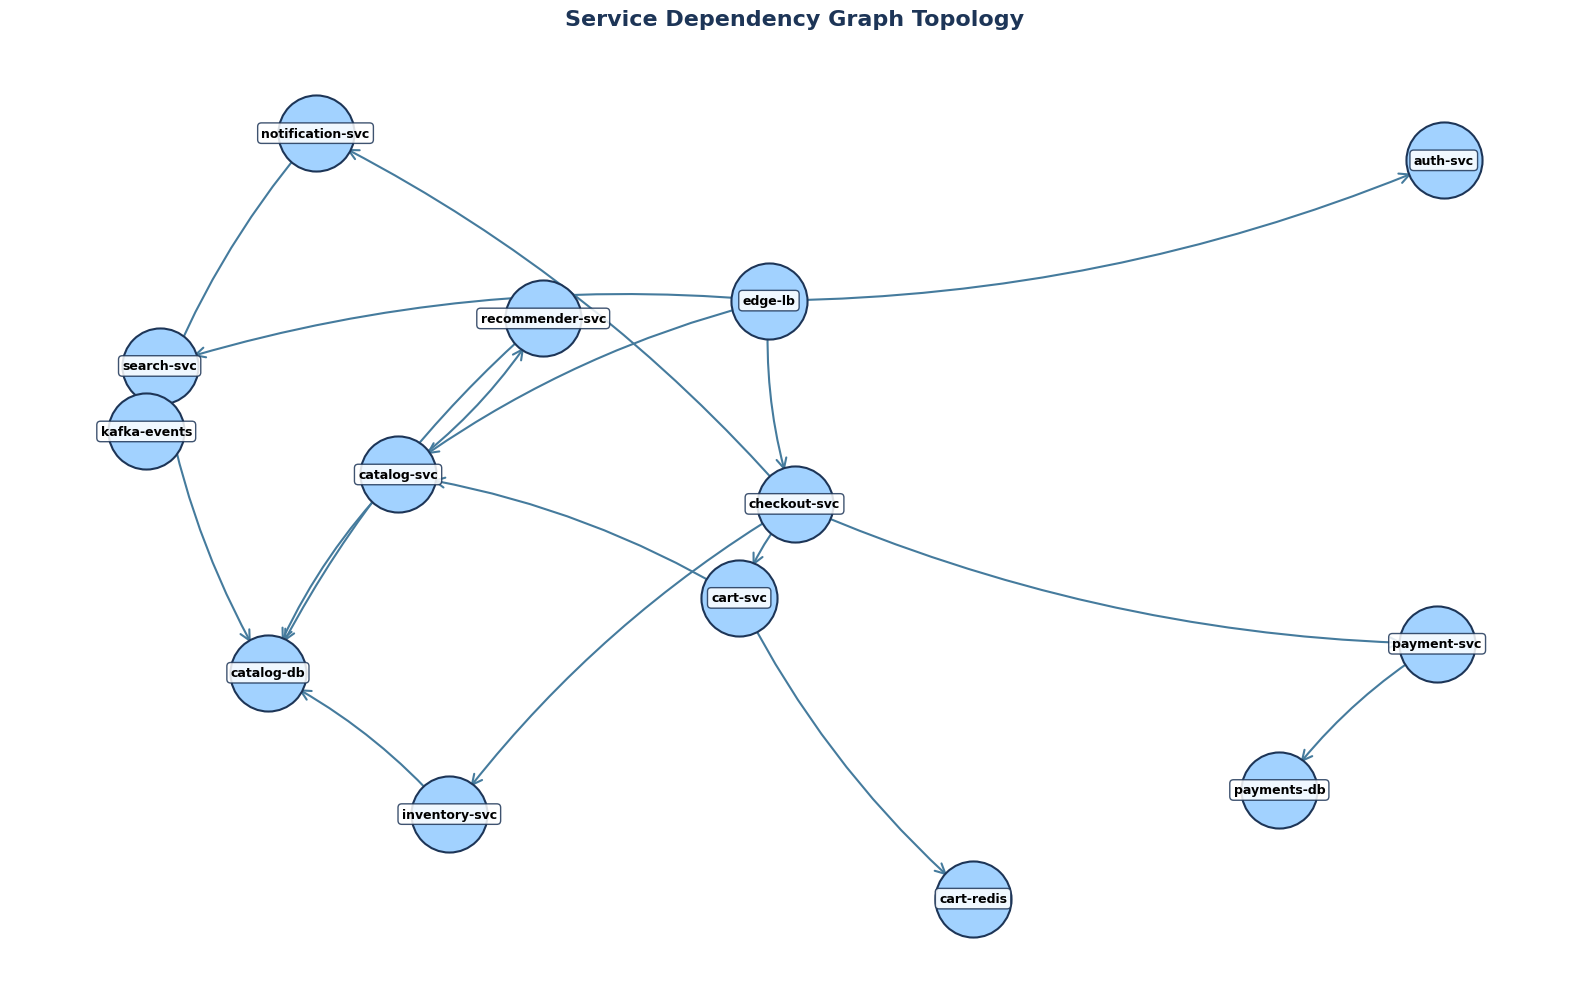

In [115]:
import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(16, 10))

pos = nx.spring_layout(graph, k=1.2, iterations=100, seed=42)

nx.draw_networkx_nodes(
    graph, pos, 
    node_size=3000, 
    node_color='#a2d2ff',
    edgecolors='#1d3557', 
    linewidths=1.5
)

nx.draw_networkx_edges(
    graph, pos, 
    width=1.5, 
    arrowsize=18, 
    edge_color='#457b9d', 
    arrowstyle='->',
    connectionstyle='arc3,rad=0.1', 
    min_target_margin=25
)

for node, (x, y) in pos.items():
    plt.text(
        x, y, 
        s=node, 
        fontsize=9, 
        fontweight='bold', 
        horizontalalignment='center', 
        verticalalignment='center',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#1d3557", alpha=0.85, lw=1)
    )

plt.title("Service Dependency Graph Topology", fontsize=16, fontweight='bold', color='#1d3557', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

## Time-Window + Topology

In [110]:
SEVERITY_RANK = {"crit": 2, "warn": 1, "info": 0}

def correlate(alerts, graph, gap_sec=30, max_hop=2):
    seen_fp: set[str] = set()
    deduped: list[dict] = []
    for a in alerts:
        fp = fingerprint(a)
        if fp not in seen_fp:
            seen_fp.add(fp)
            deduped.append(a)

    sessions = session_groups(deduped, gap_sec=gap_sec)

    clusters = []
    for s_idx, session_alerts in enumerate(sessions):
        for g_idx, group in enumerate(topology_group(session_alerts, graph, max_hop)):
            ts_sorted = sorted(a["ts"] for a in group)
            clusters.append({
                "cluster_id":   f"c-{s_idx:03d}-{g_idx:03d}",
                "alert_count":  len(group),
                "services":     sorted({a["service"] for a in group}),
                "time_range":   [ts_sorted[0], ts_sorted[-1]],
                "max_severity": max(
                    (a["severity"] for a in group),
                    key=lambda s: SEVERITY_RANK.get(s, 0)
                ),
                "fingerprints": sorted({fingerprint(a) for a in group}),
            })

    n_in  = len(alerts)
    n_out = len(clusters)
    print(f"[dedup]    {n_in} -> {len(deduped)} alerts (removed {n_in - len(deduped)} duplicates)")
    print(f"[sessions] {len(sessions)} session(s)  (gap_sec={gap_sec})")
    print(f"[clusters] {n_out} cluster(s),  reduction_ratio={round(1 - n_out/n_in, 4)}")
    return clusters

my_correlations = correlate(alert_sample, graph, gap_sec=30)

print()
for corr in my_correlations:
    print(corr)

reduction_ratio = round(1 - len(my_correlations) / len(alert_sample), 4)
print(f"\nreduction_ratio = {reduction_ratio}")


[dedup]    20 -> 17 alerts (removed 3 duplicates)
[sessions] 6 session(s)  (gap_sec=30)
[clusters] 6 cluster(s),  reduction_ratio=0.7

{'cluster_id': 'c-000-000', 'alert_count': 9, 'services': ['cart-svc', 'checkout-svc', 'edge-lb', 'notification-svc', 'payment-svc'], 'time_range': ['2026-06-12T09:42:01Z', '2026-06-12T09:43:50Z'], 'max_severity': 'crit', 'fingerprints': ['cart-svc|latency_p99_ms|warn', 'checkout-svc|downstream_payment_error_rate|crit', 'checkout-svc|latency_p99_ms|warn', 'edge-lb|upstream_5xx_rate|warn', 'notification-svc|queue_lag_ms|warn', 'payment-svc|db_connection_pool_used_ratio|crit', 'payment-svc|db_connection_pool_used_ratio|warn', 'payment-svc|error_rate|warn', 'payment-svc|latency_p99_ms|crit']}
{'cluster_id': 'c-001-000', 'alert_count': 1, 'services': ['checkout-svc'], 'time_range': ['2026-06-12T09:44:30Z', '2026-06-12T09:44:30Z'], 'max_severity': 'crit', 'fingerprints': ['checkout-svc|request_drop_rate|crit']}
{'cluster_id': 'c-002-000', 'alert_count': 1, '

In [106]:
import os
os.makedirs("results", exist_ok=True)

data = {
    "input_alerts":    len(alert_sample),
    "output_clusters": len(my_correlations),
    "reduction_ratio": reduction_ratio,
    "clusters":        my_correlations,
}

with open("results/cluster_summary.json", "w", encoding="utf-8") as f:
    json.dump(data, f, indent=2, ensure_ascii=False)

print(json.dumps(data, indent=2, ensure_ascii=False))


{
  "input_alerts": 20,
  "output_clusters": 6,
  "reduction_ratio": 0.7,
  "clusters": [
    {
      "cluster_id": "c-000-000",
      "alert_count": 9,
      "services": [
        "cart-svc",
        "checkout-svc",
        "edge-lb",
        "notification-svc",
        "payment-svc"
      ],
      "time_range": [
        "2026-06-12T09:42:01Z",
        "2026-06-12T09:43:50Z"
      ],
      "max_severity": "crit",
      "fingerprints": [
        "cart-svc|latency_p99_ms|warn",
        "checkout-svc|downstream_payment_error_rate|crit",
        "checkout-svc|latency_p99_ms|warn",
        "edge-lb|upstream_5xx_rate|warn",
        "notification-svc|queue_lag_ms|warn",
        "payment-svc|db_connection_pool_used_ratio|crit",
        "payment-svc|db_connection_pool_used_ratio|warn",
        "payment-svc|error_rate|warn",
        "payment-svc|latency_p99_ms|crit"
      ]
    },
    {
      "cluster_id": "c-001-000",
      "alert_count": 1,
      "services": [
        "checkout-svc"
      ],